In [ ]:
from google.colab import files
uploaded = files.upload()  # select all 9 Olist CSVs at once

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


In [ ]:
import pandas as pd
import sqlite3

# Connect to (or create) the SQLite database
conn = sqlite3.connect('olist.db')

# Map filenames to table names
csv_files = {
    'olist_customers_dataset.csv': 'customers',
    'olist_orders_dataset.csv': 'orders',
    'olist_order_items_dataset.csv': 'order_items',
    'olist_order_payments_dataset.csv': 'order_payments',
    'olist_order_reviews_dataset.csv': 'order_reviews',
    'olist_products_dataset.csv': 'products',
    'olist_sellers_dataset.csv': 'sellers',
    'olist_geolocation_dataset.csv': 'geolocation',
    'product_category_name_translation.csv': 'category_translation'
}

for filename, table_name in csv_files.items():
    df = pd.read_csv(filename)
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    print(f"Loaded {table_name}: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded customers: 99441 rows, 5 columns
Loaded orders: 99441 rows, 8 columns
Loaded order_items: 112650 rows, 7 columns
Loaded order_payments: 103886 rows, 5 columns
Loaded order_reviews: 99224 rows, 7 columns
Loaded products: 32951 rows, 9 columns
Loaded sellers: 3095 rows, 4 columns
Loaded geolocation: 1000163 rows, 5 columns
Loaded category_translation: 71 rows, 2 columns


In [ ]:
# List all tables
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

# Quick peek at orders table
pd.read_sql_query("SELECT * FROM orders LIMIT 5;", conn)

                   name
0             customers
1                orders
2           order_items
3        order_payments
4         order_reviews
5              products
6               sellers
7           geolocation
8  category_translation


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
import sqlite3
conn = sqlite3.connect('olist.db')

def run_query(query):
    return pd.read_sql_query(query, conn)

In [ ]:
query1 = """
SELECT
    substr(o.order_purchase_timestamp, 1, 7) AS order_month,
    SUM(oi.price) AS total_revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY order_month
ORDER BY order_month;
"""

result1 = run_query(query1)
result1

,order_month,total_revenue
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


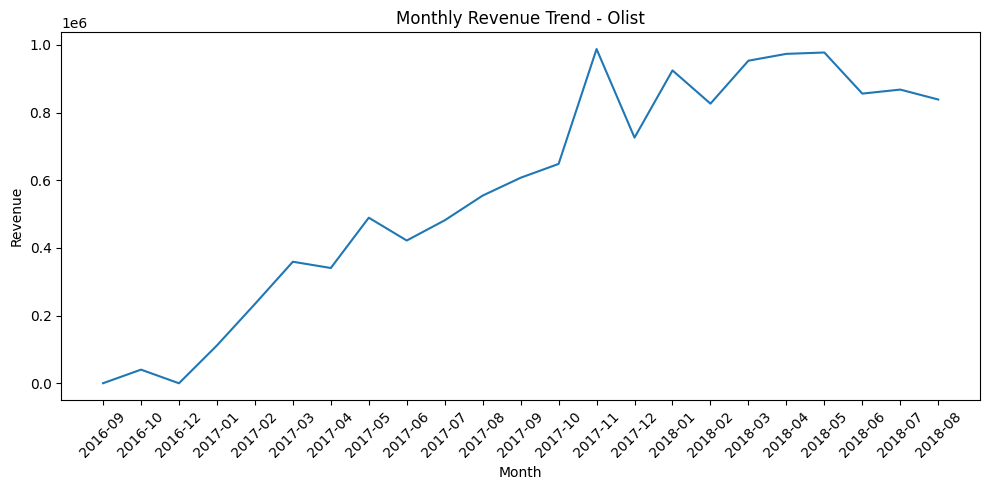

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(result1['order_month'], result1['total_revenue'])
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend - Olist')
plt.tight_layout()
plt.show()

In [ ]:
query2 = """
SELECT
    t.product_category_name_english AS category,
    SUM(oi.price) AS total_revenue,
    COUNT(oi.order_id) AS total_items_sold
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation t ON p.product_category_name = t.product_category_name
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10;
"""

result2 = run_query(query2)
result2

,category,total_revenue,total_items_sold
0,health_beauty,1258681.34,9670
1,watches_gifts,1205005.68,5991
2,bed_bath_table,1036988.68,11115
3,sports_leisure,988048.97,8641
4,computers_accessories,911954.32,7827
5,furniture_decor,729762.49,8334
6,cool_stuff,635290.85,3796
7,housewares,632248.66,6964
8,auto,592720.11,4235
9,garden_tools,485256.46,4347


In [ ]:
query2b = """
SELECT
    t.product_category_name_english AS category,
    SUM(oi.price) AS total_revenue,
    COUNT(oi.order_id) AS total_items_sold,
    ROUND(SUM(oi.price) * 1.0 / COUNT(oi.order_id), 2) AS avg_price_per_item
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation t ON p.product_category_name = t.product_category_name
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10;
"""

result2b = run_query(query2b)
result2b

,category,total_revenue,total_items_sold,avg_price_per_item
0,health_beauty,1258681.34,9670,130.16
1,watches_gifts,1205005.68,5991,201.14
2,bed_bath_table,1036988.68,11115,93.30
3,sports_leisure,988048.97,8641,114.34
4,computers_accessories,911954.32,7827,116.51
5,furniture_decor,729762.49,8334,87.56
6,cool_stuff,635290.85,3796,167.36
7,housewares,632248.66,6964,90.79
8,auto,592720.11,4235,139.96
9,garden_tools,485256.46,4347,111.63


In [ ]:
query3 = """
SELECT
    c.customer_state AS state,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY state
ORDER BY total_orders DESC
LIMIT 10;
"""

result3 = run_query(query3)
result3

,state,total_orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


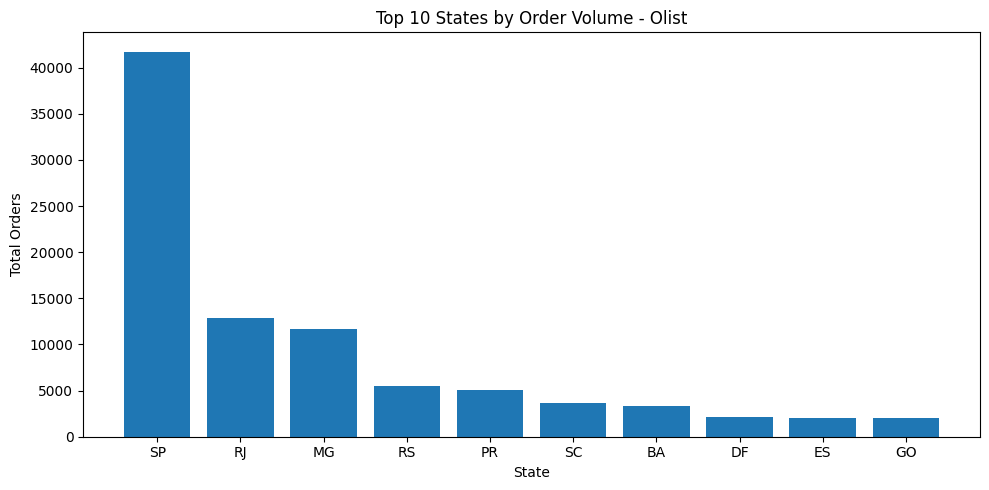

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(result3['state'], result3['total_orders'])
plt.xlabel('State')
plt.ylabel('Total Orders')
plt.title('Top 10 States by Order Volume - Olist')
plt.tight_layout()
plt.show()

In [ ]:
query4 = """
SELECT
    CASE
        WHEN julianday(o.order_delivered_customer_date) > julianday(o.order_estimated_delivery_date)
        THEN 'Delayed'
        ELSE 'On Time'
    END AS delivery_status,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    COUNT(*) AS total_orders
FROM orders o
JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY delivery_status;
"""

result4 = run_query(query4)
result4

,delivery_status,avg_review_score,total_orders
0,Delayed,2.57,7701
1,On Time,4.29,88658


In [ ]:
query5 = """
SELECT
    oi.seller_id,
    COUNT(DISTINCT oi.order_id) AS total_orders,
    SUM(oi.price) AS total_revenue
FROM order_items oi
GROUP BY oi.seller_id
ORDER BY total_revenue DESC
LIMIT 10;
"""

result5 = run_query(query5)
result5

,seller_id,total_orders,total_revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63
1,53243585a1d6dc2643021fd1853d8905,358,222776.05
2,4a3ca9315b744ce9f8e9374361493884,1806,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,585,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,982,187923.89
5,7e93a43ef30c4f03f38b393420bc753a,336,176431.87
6,da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57
7,7a67c85e85bb2ce8582c35f2203ad736,1160,141745.53
8,1025f0e2d44d7041d6cf58b6550e0bfa,915,138968.55
9,955fee9216a65b617aa5c0531780ce60,1287,135171.70


In [ ]:
result1.to_csv('revenue_trends.csv', index=False)
result2.to_csv('top_categories.csv', index=False)
result3.to_csv('state_orders.csv', index=False)
result4.to_csv('delivery_review_impact.csv', index=False)
result5.to_csv('top_sellers.csv', index=False)

from google.colab import files
files.download('revenue_trends.csv')
files.download('top_categories.csv')
files.download('state_orders.csv')
files.download('delivery_review_impact.csv')
files.download('top_sellers.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sql_script = """
-- Q1: Revenue Trends Over Time
""" + query1 + """

-- Q2: Top-Selling Categories
""" + query2 + """

-- Q3: State-wise Order Distribution
""" + query3 + """

-- Q4: Delivery Delay Impact on Reviews
""" + query4 + """

-- Q5: Top-Performing Sellers
""" + query5

with open('olist_queries.sql', 'w') as f:
    f.write(sql_script)

files.download('olist_queries.sql')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>